# Power Analysis for Mycorrhizal Inoculation Field Trials

Funga's field trials compare two groups of planted forest sites: those where seedlings were inoculated with native fungal communities, and uninoculated control sites. The goal is to detect whether inoculation produces a meaningful improvement in tree growth — measured as annual diameter increment (inches/year), the same metric computed in Notebook 1.

This notebook answers one question: **how many sites does a well-designed trial need?**

To answer it, we need three inputs:
1. **The variance structure of tree growth** — estimated in Notebook 1 from 785,988 southern pine tree records across 65,513 FIA plots. The key finding: ICC = 0.62, meaning 62% of growth variation is *between* sites, not between individual trees on the same site.
2. **A target effect size** — how large a growth improvement should the trial be designed to detect? We use a range drawn from published ECM field trial meta-analyses rather than a single assumed value.
3. **The trial design** — sites (plots) are the experimental unit; trees are measurement units within sites. This is a cluster-randomized design.

**Run this notebook from the `notebooks/` directory.**

## 1. Load Variance Parameters

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Load variance parameters estimated in Notebook 1
with open("../outputs/variance_params.json") as f:
    params = json.load(f)

var_between = params["var_between"]   # between-plot variance
var_within  = params["var_within"]    # within-plot variance
icc         = params["icc"]
var_total   = var_between + var_within
mean_growth = params["mean_growth"]   # mean annual diameter growth (in/yr)

print("Variance parameters from Notebook 1:")
print(f"  Between-plot variance: {var_between:.6f}")
print(f"  Within-plot variance:  {var_within:.6f}")
print(f"  Total variance:        {var_total:.6f}")
print(f"  ICC:                   {icc:.4f}")
print(f"  Mean annual growth:    {mean_growth:.4f} in/yr")
print(f"\nSource: {params['notes']}")

Variance parameters from Notebook 1:
  Between-plot variance: 0.021542
  Within-plot variance:  0.013039
  Total variance:        0.034581
  ICC:                   0.6229
  Mean annual growth:    0.1882 in/yr

Source: Fit on annual_growth ~ 1 + (1|PLT_CN) via REML. var_between=between-plot, var_within=within-plot (residual).


## 2. Trial Design & Power Formula

### The experimental structure

Funga plants inoculated seedlings across an entire site and compares growth against uninoculated control sites. This means **the site is the experimental unit** — it receives the treatment as a whole. Individual trees within a site are measurement units, not independent experimental units.

This structure is a **cluster-randomized trial**: sites are randomized to treatment or control, and trees within each site share the same treatment condition and the same underlying soil environment.

The consequence, quantified in Notebook 1, is that trees within a site are not independent. With ICC = 0.62, trees on the same site share 62% of their growth variation in common. Adding more trees to a site yields rapidly diminishing information — the binding design constraint is the **number of sites**, not trees per site.

### The power formula

For a two-arm cluster-randomized trial, the required number of sites per arm is:

$$n_c = \frac{2 \, (z_{\alpha/2} + z_\beta)^2 \, (\sigma^2_b + \sigma^2_w \, / \, m)}{\delta^2}$$

Where:
- $n_c$ = sites per arm (total trial sites = $2 n_c$)
- $\sigma^2_b$ = between-site variance (0.0215, from Notebook 1)
- $\sigma^2_w$ = within-site variance (0.0130, from Notebook 1)
- $m$ = trees measured per site
- $\delta$ = expected difference in mean annual growth between arms (in/yr)
- $z_{\alpha/2}$ = 1.96 for a two-sided test at $\alpha = 0.05$
- $z_\beta$ = 0.84 for 80% power, 1.28 for 90% power

The term $\sigma^2_b + \sigma^2_w / m$ is the variance of a single site's mean growth. The between-site component ($\sigma^2_b$) is irreducible — no matter how many trees you measure, you cannot average away site-level differences. The within-site component ($\sigma^2_w / m$) shrinks as you add trees, but with ICC = 0.62, the between-site term already dominates at small $m$. This is why trees per site is a weak lever.

In [2]:
def required_sites_per_arm(delta, m, var_between, var_within, alpha=0.05, power=0.80):
    """
    Required number of sites per arm in a two-arm cluster-randomized trial.

    Parameters
    ----------
    delta       : float — expected difference in mean annual growth (in/yr)
    m           : int   — trees measured per site
    var_between : float — between-site variance (sigma^2_b)
    var_within  : float — within-site variance (sigma^2_w)
    alpha       : float — two-sided significance level (default 0.05)
    power       : float — target power (default 0.80)

    Returns
    -------
    n_c : float — sites per arm (round up for integer requirement)
    """
    z_alpha = stats.norm.ppf(1 - alpha / 2)
    z_beta  = stats.norm.ppf(power)
    var_cluster_mean = var_between + var_within / m
    n_c = 2 * (z_alpha + z_beta)**2 * var_cluster_mean / delta**2
    return n_c


# Effect sizes: % improvement in mean annual growth, converted to absolute (in/yr)
# Mean annual growth (mean_growth = 0.18 in/yr) loaded from variance_params.json
effect_pcts  = [10, 20, 30]
effect_deltas = [p / 100 * mean_growth for p in effect_pcts]

print(f"Mean annual growth (control baseline): {mean_growth:.4f} in/yr")
print()
print("Effect sizes:")
for pct, delta in zip(effect_pcts, effect_deltas):
    print(f"  {pct}% improvement  →  δ = {delta:.4f} in/yr")

Mean annual growth (control baseline): 0.1882 in/yr

Effect sizes:
  10% improvement  →  δ = 0.0188 in/yr
  20% improvement  →  δ = 0.0376 in/yr
  30% improvement  →  δ = 0.0564 in/yr


## 3. Power Curves

How does statistical power grow as we add more sites? The plots below show power as a function of sites per arm, for each of the three effect size scenarios. A horizontal dashed line marks 80% power — the conventional minimum for a well-designed trial.

The required site counts at 80% power are printed below each figure, giving a concrete planning number for each scenario.

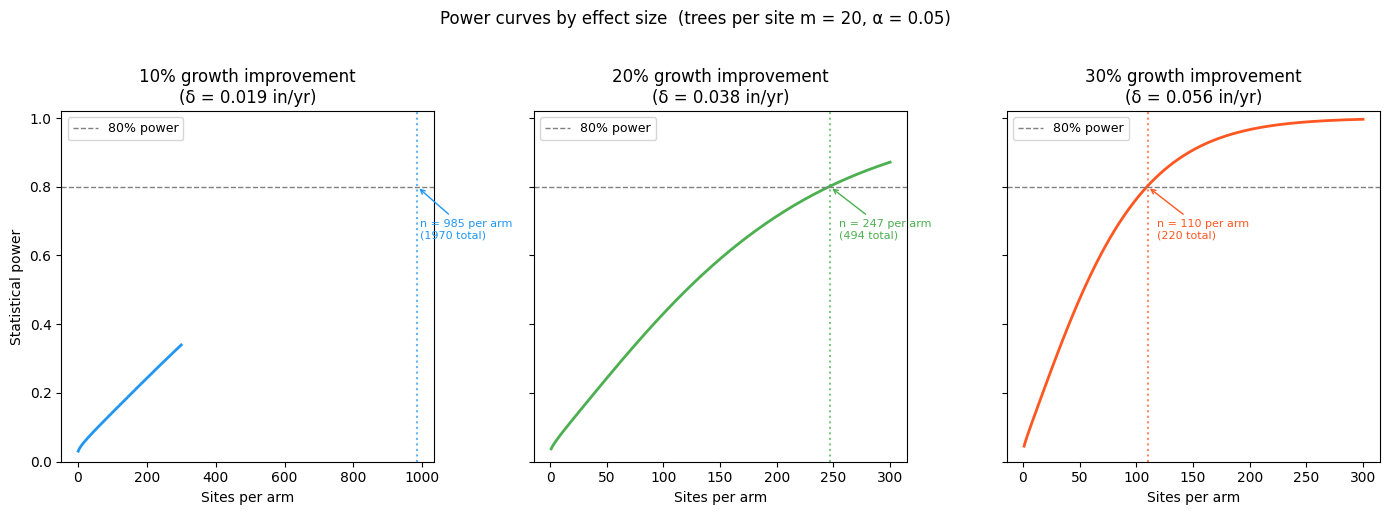

Required sites per arm at 80% power (m = 20 trees/site):
  10% effect: 985 sites per arm  (1970 total sites)
  20% effect: 247 sites per arm  (494 total sites)
  30% effect: 110 sites per arm  (220 total sites)


In [3]:
def compute_power(n_c, delta, m, var_between, var_within, alpha=0.05):
    """Statistical power for a two-arm cluster-randomized trial."""
    z_alpha = stats.norm.ppf(1 - alpha / 2)
    var_cluster_mean = var_between + var_within / m
    se = np.sqrt(2 * var_cluster_mean / n_c)
    return stats.norm.cdf(abs(delta) / se - z_alpha)


# Fixed design parameters
M_DEFAULT = 20          # trees measured per site
ALPHA     = 0.05
POWER_TARGET = 0.80

n_sites_range = np.arange(1, 301)
colors = ["#2196F3", "#4CAF50", "#FF5722"]   # blue, green, orange

fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)

for ax, pct, delta, color in zip(axes, effect_pcts, effect_deltas, colors):
    power_curve = [compute_power(n, delta, M_DEFAULT, var_between, var_within, ALPHA)
                   for n in n_sites_range]

    ax.plot(n_sites_range, power_curve, color=color, linewidth=2)
    ax.axhline(POWER_TARGET, color="gray", linestyle="--", linewidth=1, label="80% power")
    ax.set_ylim(0, 1.02)
    ax.set_xlabel("Sites per arm")
    ax.set_title(f"{pct}% growth improvement\n(δ = {delta:.3f} in/yr)")
    ax.legend(fontsize=9)

    # Required sites at 80% power
    n_required = int(np.ceil(required_sites_per_arm(delta, M_DEFAULT, var_between, var_within,
                                                     alpha=ALPHA, power=POWER_TARGET)))
    ax.axvline(n_required, color=color, linestyle=":", linewidth=1.5, alpha=0.7)
    ax.annotate(f"n = {n_required} per arm\n({2*n_required} total)",
                xy=(n_required, POWER_TARGET),
                xytext=(n_required + 8, POWER_TARGET - 0.15),
                fontsize=8, color=color,
                arrowprops=dict(arrowstyle="->", color=color, lw=1))

axes[0].set_ylabel("Statistical power")

fig.suptitle(f"Power curves by effect size  (trees per site m = {M_DEFAULT}, α = {ALPHA})",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

print("Required sites per arm at 80% power (m = 20 trees/site):")
for pct, delta in zip(effect_pcts, effect_deltas):
    n = int(np.ceil(required_sites_per_arm(delta, M_DEFAULT, var_between, var_within)))
    print(f"  {pct}% effect: {n} sites per arm  ({2*n} total sites)")

## 4. Does Trees Per Site Matter?

The formula contains two design levers: number of sites ($n_c$) and trees measured per site ($m$). Intuitively, measuring more trees per site should improve precision. But how much does it actually help when ICC is this high?

The plot below fixes the effect size at 20% and shows power curves for four values of $m$ — ranging from 5 to 30 trees per site. If the lines are close together, it means trees per site is a weak lever and all the design effort should go into securing more sites.

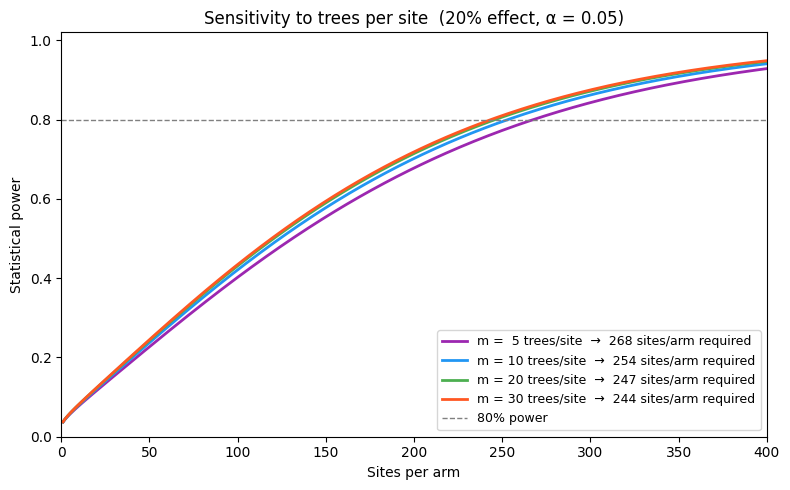

Required sites per arm at 80% power — 20% effect, varying trees per site:
  m =  5 trees/site:  268 sites per arm  (536 total)
  m = 10 trees/site:  254 sites per arm  (508 total)
  m = 20 trees/site:  247 sites per arm  (494 total)
  m = 30 trees/site:  244 sites per arm  (488 total)

Why m barely matters — variance of site mean by trees per site:
  (σ²_b is irreducible regardless of m; σ²_w/m shrinks but starts small)
  m =  5:  σ²_b + σ²_w/m = 0.02154 + 0.00261 = 0.02415  (10.8% is reducible by adding more trees)
  m = 10:  σ²_b + σ²_w/m = 0.02154 + 0.00130 = 0.02285  (5.7% is reducible by adding more trees)
  m = 20:  σ²_b + σ²_w/m = 0.02154 + 0.00065 = 0.02219  (2.9% is reducible by adding more trees)
  m = 30:  σ²_b + σ²_w/m = 0.02154 + 0.00043 = 0.02198  (2.0% is reducible by adding more trees)


In [4]:
# Sensitivity to trees per site — fix effect at 20%
delta_20pct = 0.20 * mean_growth
m_values    = [5, 10, 20, 30]
n_range     = np.arange(1, 401)
line_colors = ["#9C27B0", "#2196F3", "#4CAF50", "#FF5722"]

fig, ax = plt.subplots(figsize=(8, 5))

for m, color in zip(m_values, line_colors):
    curve  = [compute_power(n, delta_20pct, m, var_between, var_within) for n in n_range]
    n_req  = int(np.ceil(required_sites_per_arm(delta_20pct, m, var_between, var_within)))
    ax.plot(n_range, curve, linewidth=2, color=color,
            label=f"m = {m:2d} trees/site  →  {n_req} sites/arm required")

ax.axhline(0.80, color="gray", linestyle="--", linewidth=1, label="80% power")
ax.set_xlabel("Sites per arm")
ax.set_ylabel("Statistical power")
ax.set_title("Sensitivity to trees per site  (20% effect, α = 0.05)")
ax.set_xlim(0, 400)
ax.set_ylim(0, 1.02)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print("Required sites per arm at 80% power — 20% effect, varying trees per site:")
for m in m_values:
    n = int(np.ceil(required_sites_per_arm(delta_20pct, m, var_between, var_within)))
    print(f"  m = {m:2d} trees/site:  {n} sites per arm  ({2*n} total)")

# Compute the variance of a cluster mean to show why m barely matters
print(f"\nWhy m barely matters — variance of site mean by trees per site:")
print(f"  (σ²_b is irreducible regardless of m; σ²_w/m shrinks but starts small)")
for m in m_values:
    var_cluster = var_between + var_within / m
    pct_reducible = (var_within / m) / var_cluster * 100
    print(f"  m = {m:2d}:  σ²_b + σ²_w/m = {var_between:.5f} + {var_within/m:.5f} = {var_cluster:.5f}  "
          f"({pct_reducible:.1f}% is reducible by adding more trees)")

## 5. Sensitivity to ICC

The ICC of 0.62 was estimated from FIA data — natural forest variation across the landscape, including differences in stand age, species composition, soil type, and management history. Funga's controlled field trials would deliberately match sites on many of these factors, which reduces between-site variance and therefore reduces the ICC.

How much does a lower ICC change the required number of sites? This matters for trial planning: it tells Funga how much they can reduce the trial burden by investing in careful site selection and matching.

To vary ICC while holding total growth variance constant, we redistribute the same total variance (σ² = 0.0346) between the between-site and within-site components: σ²_b = ICC × σ², σ²_w = (1 − ICC) × σ². This isolates the effect of clustering from the overall scale of growth variation.

The vertical dashed line marks ICC = 0.62, our FIA-based estimate — the conservative upper bound.

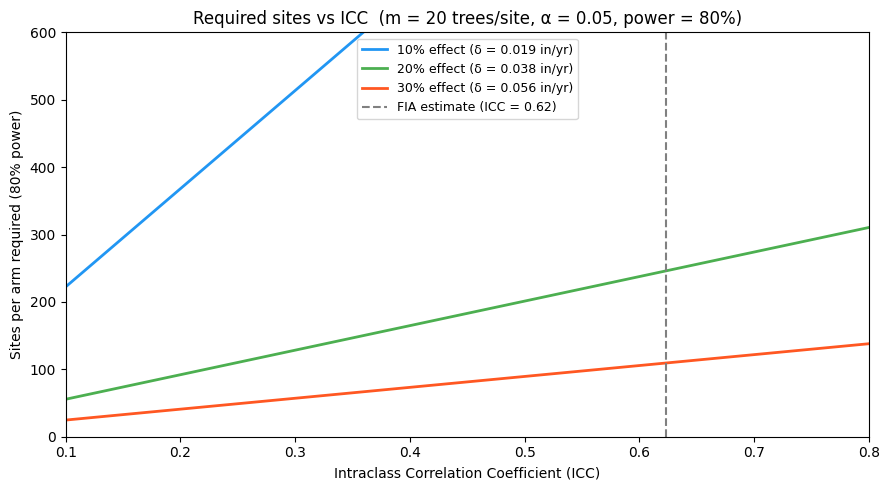

Required sites per arm at 80% power (m = 20 trees/site):
   ICC    10% effect    20% effect    30% effect
------------------------------------------------
  0.30           514           129            58
  0.40           660           165            74
  0.50           805           202            90
  0.62           980           245           109  ← FIA estimate
  0.70         1,097           275           122


In [5]:
# ICC sensitivity: required sites per arm vs ICC, for each effect size
# Total variance held constant — only the split between levels changes
icc_range = np.linspace(0.1, 0.8, 200)
m_fixed   = 20

fig, ax = plt.subplots(figsize=(9, 5))

for pct, delta, color in zip(effect_pcts, effect_deltas, colors):
    n_required_by_icc = []
    for icc_val in icc_range:
        vb = icc_val * var_total
        vw = (1 - icc_val) * var_total
        n = required_sites_per_arm(delta, m_fixed, vb, vw)
        n_required_by_icc.append(n)
    ax.plot(icc_range, n_required_by_icc, color=color, linewidth=2,
            label=f"{pct}% effect (δ = {delta:.3f} in/yr)")

ax.axvline(icc, color="gray", linestyle="--", linewidth=1.5, label=f"FIA estimate (ICC = {icc:.2f})")
ax.set_xlabel("Intraclass Correlation Coefficient (ICC)")
ax.set_ylabel("Sites per arm required (80% power)")
ax.set_title(f"Required sites vs ICC  (m = {m_fixed} trees/site, α = 0.05, power = 80%)")
ax.set_xlim(0.1, 0.8)
ax.set_ylim(0, 600)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# Print a summary table at key ICC values
icc_checkpoints = [0.3, 0.4, 0.5, 0.62, 0.7]
print(f"Required sites per arm at 80% power (m = {m_fixed} trees/site):")
print(f"{'ICC':>6}  {'10% effect':>12}  {'20% effect':>12}  {'30% effect':>12}")
print("-" * 48)
for icc_val in icc_checkpoints:
    row = []
    for delta in effect_deltas:
        vb = icc_val * var_total
        vw = (1 - icc_val) * var_total
        n = int(np.ceil(required_sites_per_arm(delta, m_fixed, vb, vw)))
        row.append(n)
    marker = "  ← FIA estimate" if icc_val == 0.62 else ""
    print(f"{icc_val:>6.2f}  {row[0]:>12,}  {row[1]:>12,}  {row[2]:>12,}{marker}")

## 6. Recommendation

### What the analysis tells us

Three findings stand out.

**1. Sites are the binding constraint — not trees per site.**
Going from 5 to 30 trees per site reduces the required site count by fewer than 25 (268 → 244 for a 20% effect). This is because 90%+ of cluster-mean variance is locked in the between-site component (σ²_b), which no amount of within-site measurement can reduce. The practical implication: once a site is established, measuring 10–15 trees per site is sufficient. The effort saved should go toward securing more sites.

**2. Effect size is the most powerful lever — but it is not a design choice.**
The difference between a 10% and 30% effect is the difference between ~1,000 and ~110 sites per arm — roughly a 9x change in trial burden for a 3x change in signal. Funga cannot choose the true effect size; it is determined by the biology of the inoculant and the site. What Funga *can* do is prioritize inoculants and sites where their data platform predicts the strongest treatment response, focusing trial resources where the expected effect is largest.

**3. Site matching directly reduces the ICC and the trial burden.**
The FIA-based ICC of 0.62 reflects natural landscape-level heterogeneity. A controlled trial where sites are matched on species, stand age, soil type, and climate will have a lower between-site variance — and therefore a lower ICC. At ICC = 0.40, a 30% effect requires 74 sites per arm (148 total); at ICC = 0.30, it drops to 58 per arm (116 total). Investing in site selection is statistically equivalent to running a fundamentally larger trial.

### Planning numbers

The table below gives concrete site counts for a range of realistic ICC values and effect sizes, at 80% power with 20 trees per site. The 10% scenario is excluded — it is not practically feasible without hundreds of matched sites per arm.

| ICC | 20% effect (sites/arm) | 30% effect (sites/arm) |
|-----|----------------------|----------------------|
| 0.30 (well-matched sites) | 129 | 58 |
| 0.40 | 165 | 74 |
| 0.50 | 202 | 90 |
| 0.62 (FIA estimate, conservative) | 247 | 110 |

*All figures: 80% power, α = 0.05, two-sided, 20 trees/site.*

### Caveats and next steps

This analysis uses FIA data from established natural and managed southern pine forests as a proxy for the variance structure in Funga's planted trial sites. Several factors could shift the estimates:

- **True ICC in controlled trials is likely lower.** FIA plots span the full range of landscape heterogeneity. Funga's sites would be deliberately matched, bringing ICC closer to 0.30–0.40 and making the trial substantially more tractable.
- **The effect size range is drawn from ECM field trial literature** (−12% to +48% for consortium inoculants), not from Funga's own trial data. If Funga has internal pilot data, those estimates should replace the assumptions here.
- **A pilot trial would sharpen all estimates.** A small initial trial (20–30 sites per arm) could estimate both the within-trial ICC and the observed effect size, allowing a better-powered confirmatory trial to be designed with far less uncertainty.

In [6]:
# Clean summary table: required sites per arm across ICC and effect size scenarios
icc_scenarios = [0.30, 0.40, 0.50, 0.62]
labels        = ["0.30 (well-matched)", "0.40", "0.50", "0.62 (FIA, conservative)"]
m_fixed       = 20

print("Required sites per arm — 80% power, α = 0.05, 20 trees/site")
print(f"{'ICC scenario':<26}  {'20% effect':>12}  {'30% effect':>12}  {'Total (30% effect)':>20}")
print("-" * 76)
for icc_val, label in zip(icc_scenarios, labels):
    vb = icc_val * var_total
    vw = (1 - icc_val) * var_total
    n20 = int(np.ceil(required_sites_per_arm(effect_deltas[1], m_fixed, vb, vw)))
    n30 = int(np.ceil(required_sites_per_arm(effect_deltas[2], m_fixed, vb, vw)))
    print(f"{label:<26}  {n20:>12,}  {n30:>12,}  {2*n30:>20,}")

Required sites per arm — 80% power, α = 0.05, 20 trees/site
ICC scenario                  20% effect    30% effect    Total (30% effect)
----------------------------------------------------------------------------
0.30 (well-matched)                  129            58                   116
0.40                                 165            74                   148
0.50                                 202            90                   180
0.62 (FIA, conservative)             245           109                   218
